In [11]:
import pandas as pd
import numpy as np
import datetime
import gc 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sparse
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

print("Packages loaded.")

Packages loaded.


**INSTALLATION & IMPORTS**

# ***EXPLORATORY DATA ANALYSIS***

**OPTIMISED LOADING & TEMPORAL SPLIT**

In [2]:
# --- CONFIGURATION ---
WEEKS_TO_KEEP = 5

# 1. Partial loading (transactions)
df = pd.read_csv('/kaggle/input/h-and-m-personalized-fashion-recommendations/transactions_train.csv', usecols=['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id'])
df['t_dat']= pd.to_datetime(df['t_dat'])

# 2. Temporal split
max_date = df['t_dat'].max()
start_date = max_date - datetime.timedelta(weeks=WEEKS_TO_KEEP)
df = df[df['t_dat'] > start_date].copy()

#3. Validation set(on which we're going to check if the model is working well.)
val_start_date = max_date - datetime.timedelta(days=7)

train = df[df['t_dat'] <= val_start_date].copy()
val = df[df['t_dat'] > val_start_date].copy()

print(f"Train set shape: {train.shape}")
print(f"Validation set shape: {val.shape}")

Train set shape: (1059723, 5)
Validation set shape: (240311, 5)


**FEATURE ENGINEERIENG (METADATA)**

In [3]:
# 2. CHARGEMENT DES METADATA COMPLÈTES (On prend TOUTES les colonnes)
print("Chargement des Articles et Clients (Toutes colonnes)...")
articles = pd.read_csv('/kaggle/input/h-and-m-personalized-fashion-recommendations/articles.csv')
customers = pd.read_csv('/kaggle/input/h-and-m-personalized-fashion-recommendations/customers.csv')

# 3. LE GRAND MERGE
# C'est ici qu'on lie tout pour voir l'influence sur les achats
print("Fusion des datasets pour analyse...")
df_full = train.merge(customers, on='customer_id', how='left')
df_full = df_full.merge(articles, on='article_id', how='left')

print(f"Dataset d'Analyse prêt : {df_full.shape}")
print("Colonnes disponibles :", df_full.columns.tolist())


Chargement des Articles et Clients (Toutes colonnes)...
Fusion des datasets pour analyse...
Dataset d'Analyse prêt : (1059723, 35)
Colonnes disponibles : ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']



--- ANALYSE DE : FN ---
❌ REJETÉ : Valeur constante (inutile).

--- ANALYSE DE : Active ---
❌ REJETÉ : Valeur constante (inutile).

--- ANALYSE DE : club_member_status ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


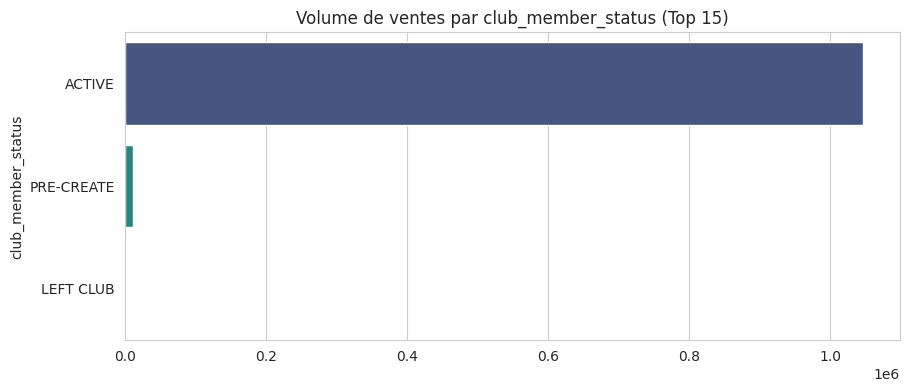

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : fashion_news_frequency ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


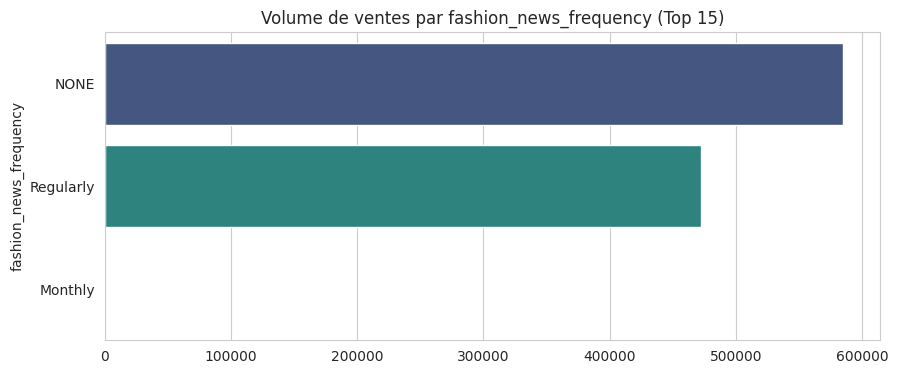

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : age ---


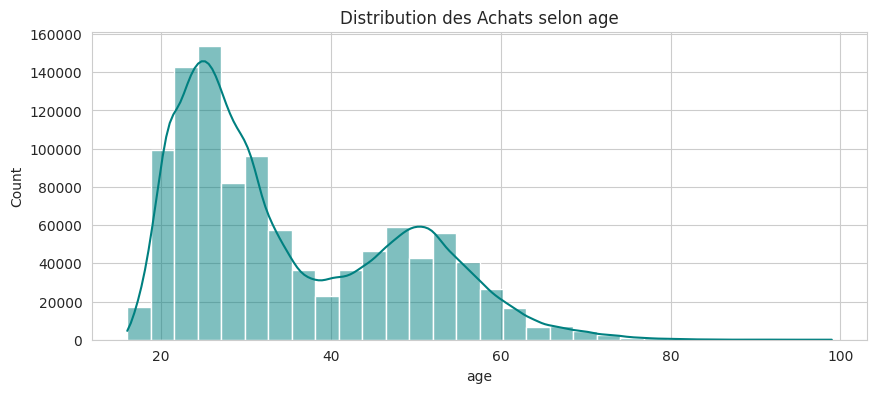

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : postal_code ---
⚠️ BRUIT PROBABLE : 152504 valeurs uniques.
C'est trop précis pour généraliser (Risque d'Overfitting).

--- ANALYSE DE : product_code ---


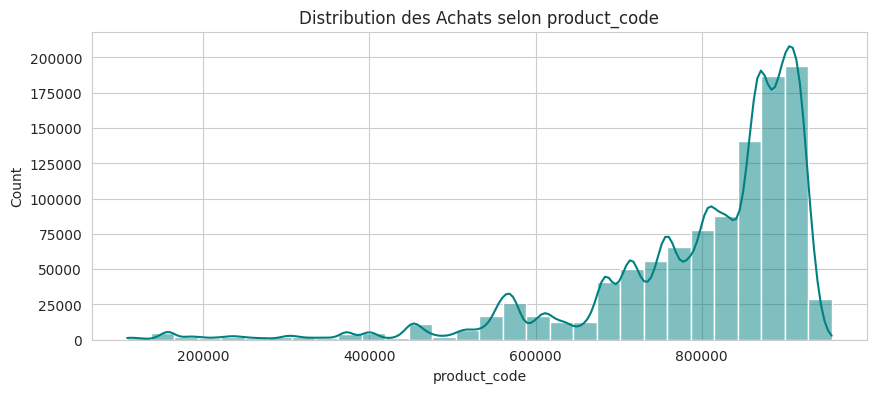

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : prod_name ---
⚠️ BRUIT PROBABLE : 15384 valeurs uniques.
C'est trop précis pour généraliser (Risque d'Overfitting).

--- ANALYSE DE : product_type_no ---


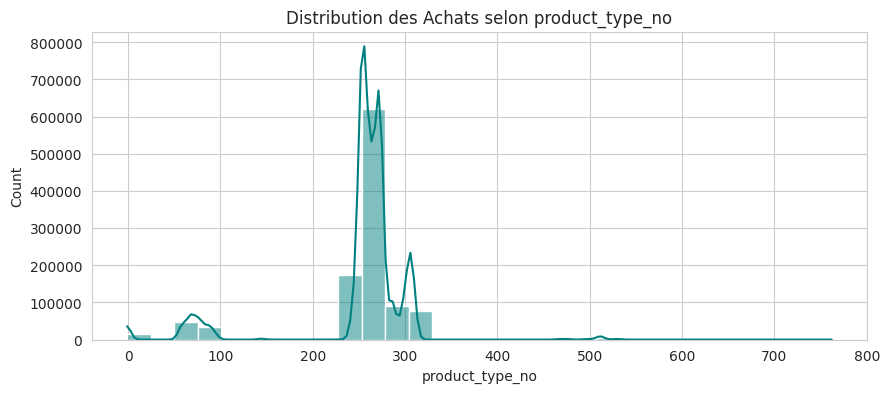

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : product_type_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


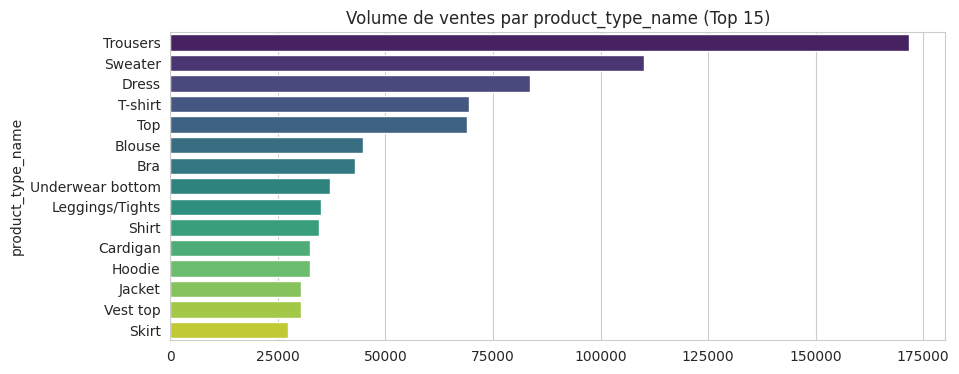

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : product_group_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


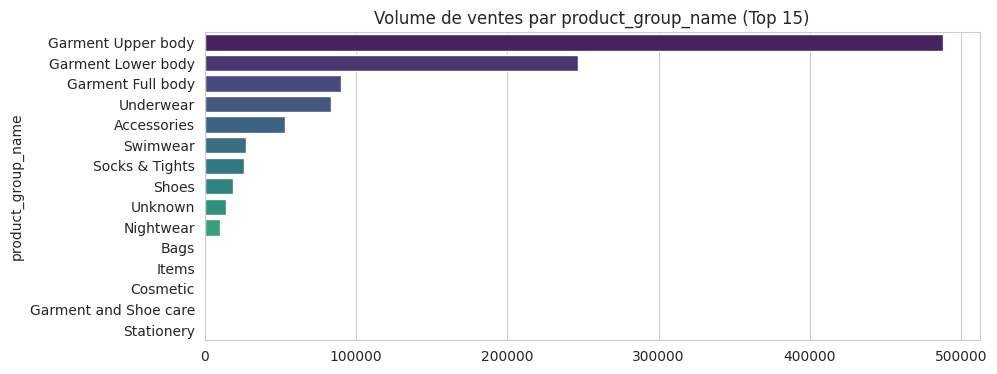

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : graphical_appearance_no ---


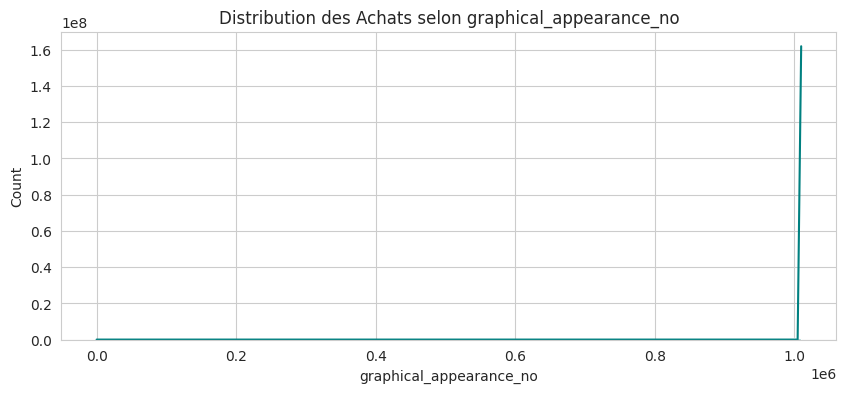

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : graphical_appearance_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


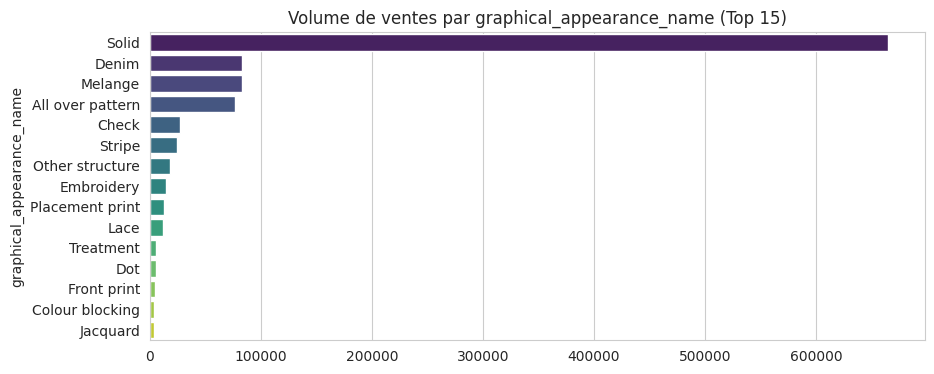

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : colour_group_code ---


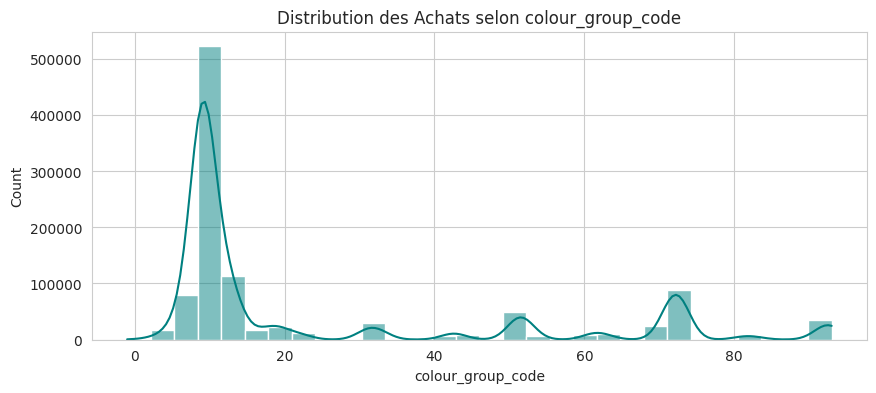

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : colour_group_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


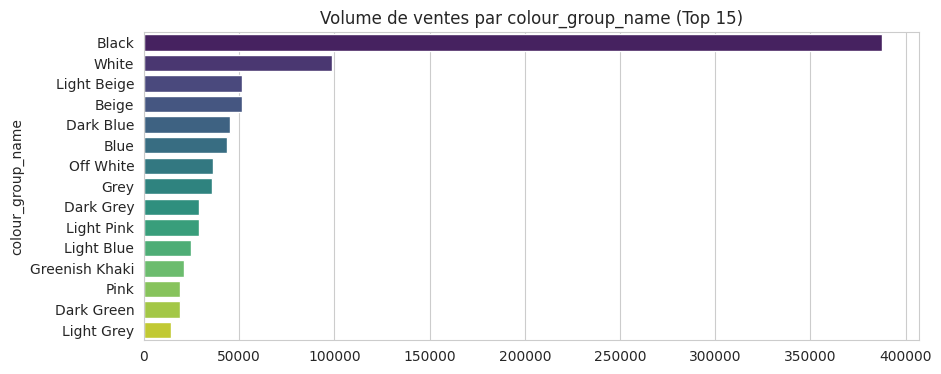

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : perceived_colour_value_id ---


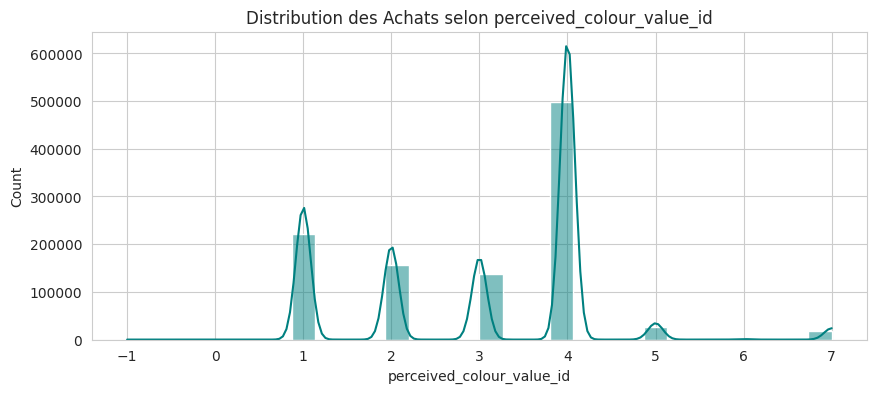

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : perceived_colour_value_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


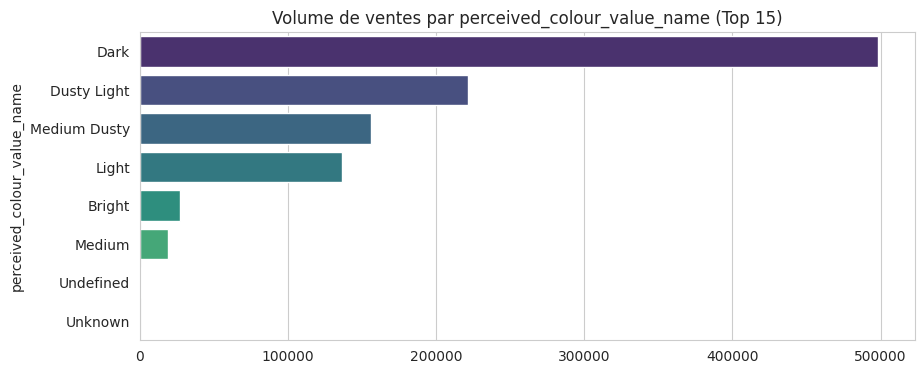

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : perceived_colour_master_id ---


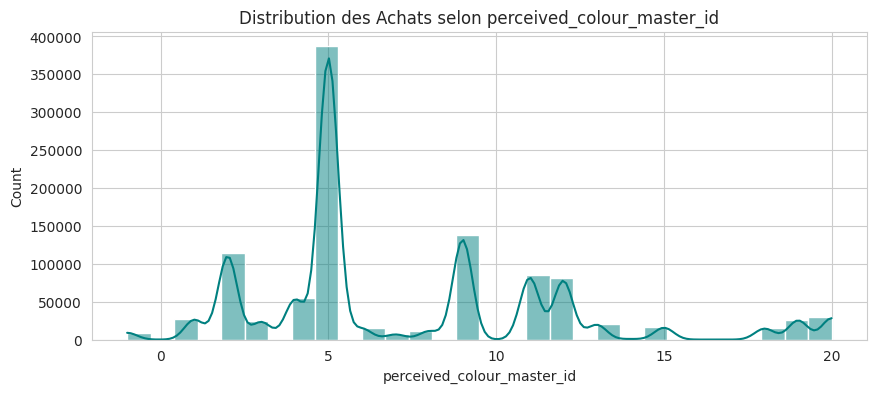

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : perceived_colour_master_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


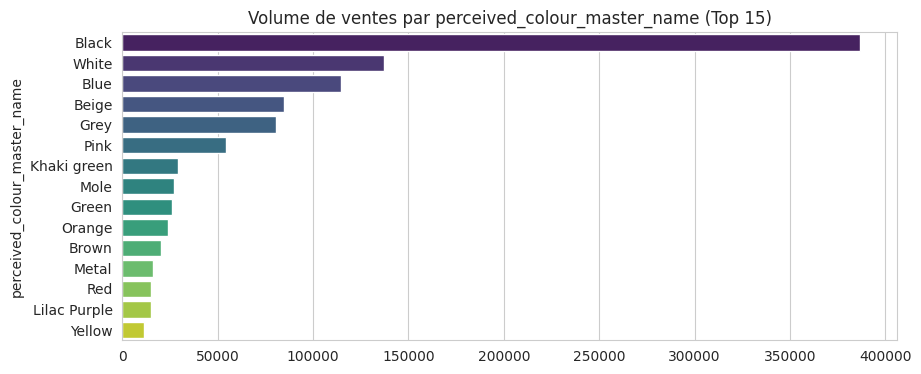

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : department_no ---


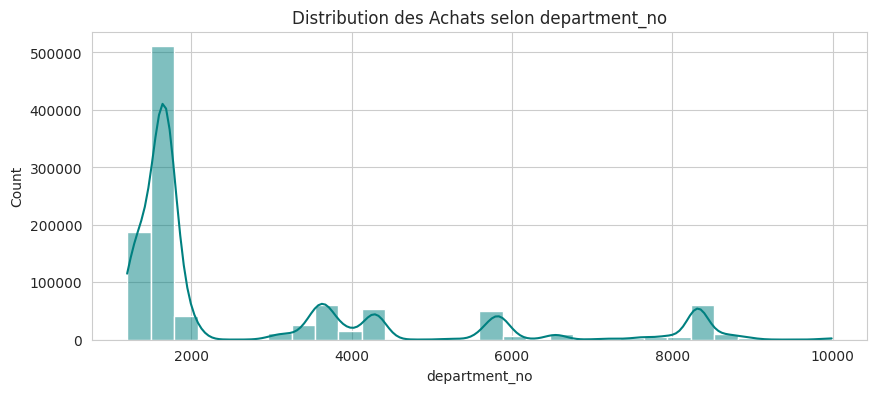

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : department_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


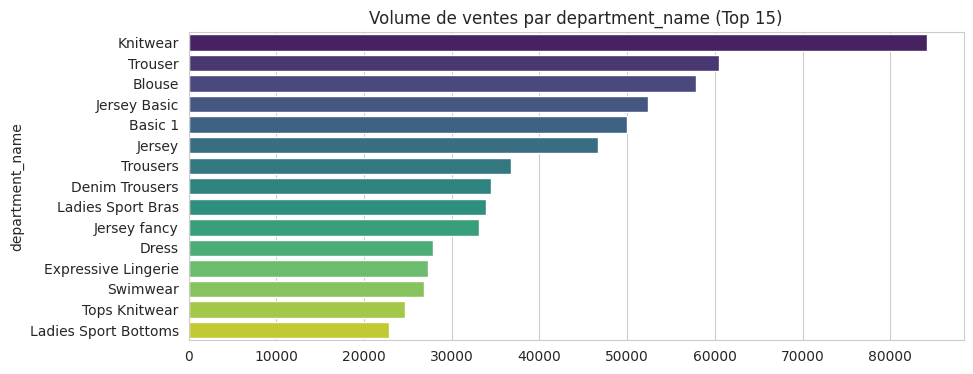

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : index_code ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


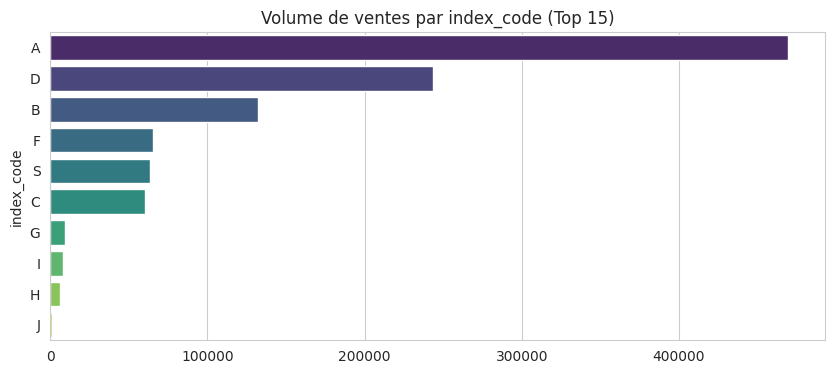

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : index_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


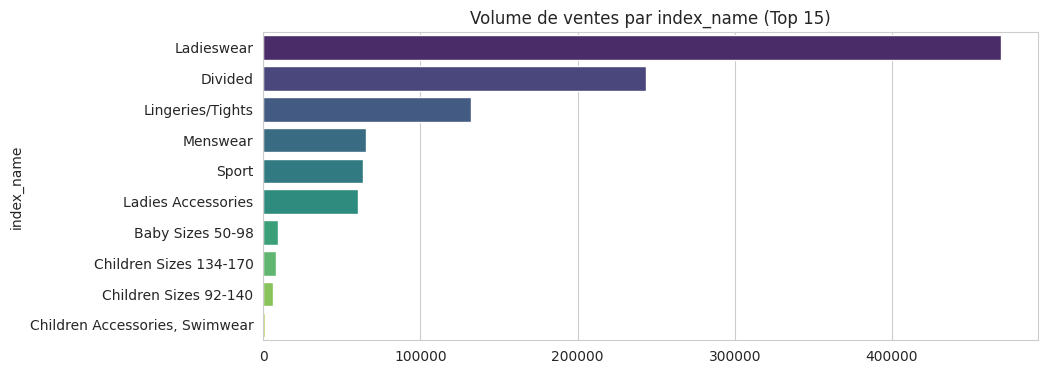

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : index_group_no ---


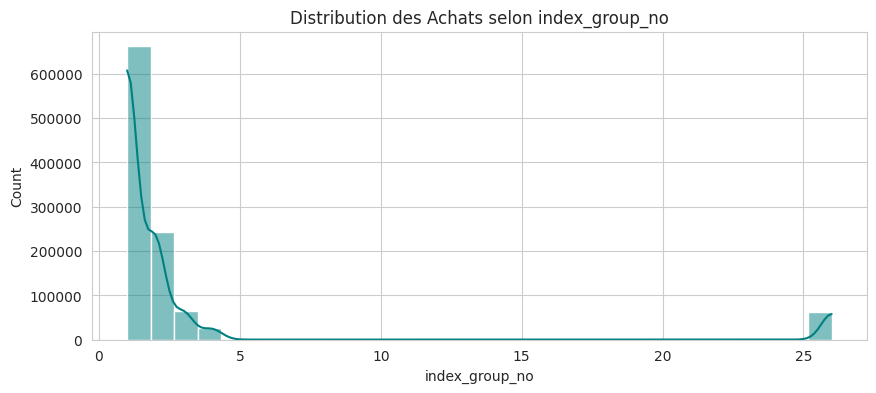

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : index_group_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


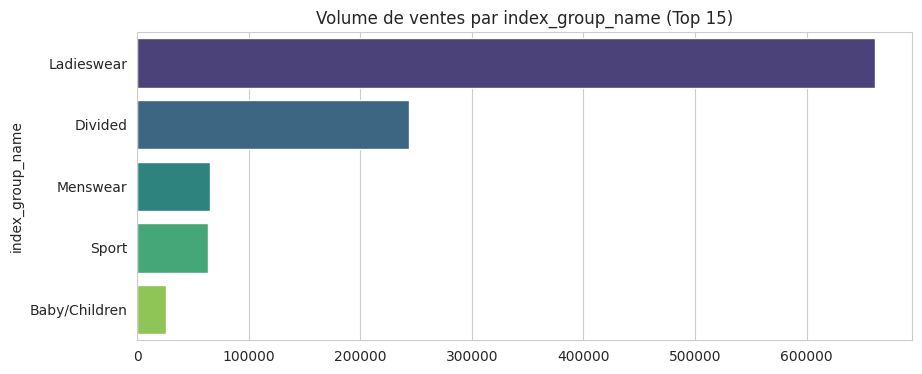

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : section_no ---


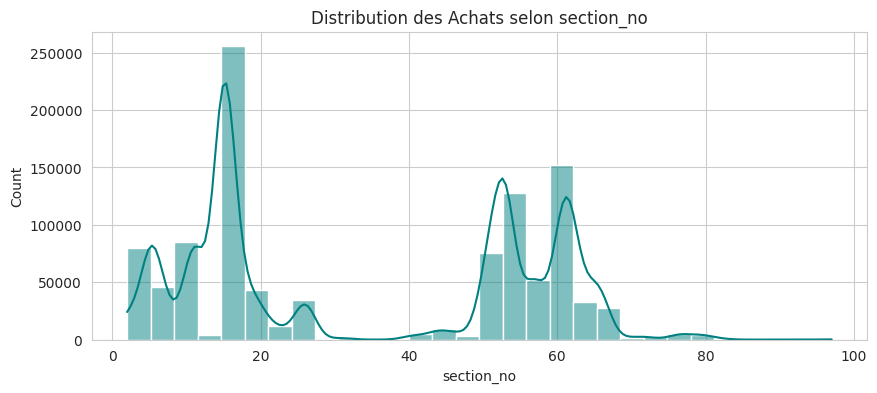

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : section_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


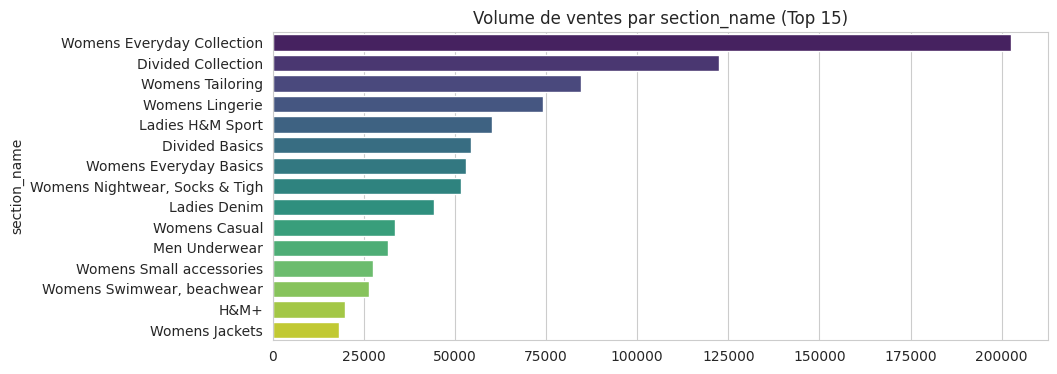

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : garment_group_no ---


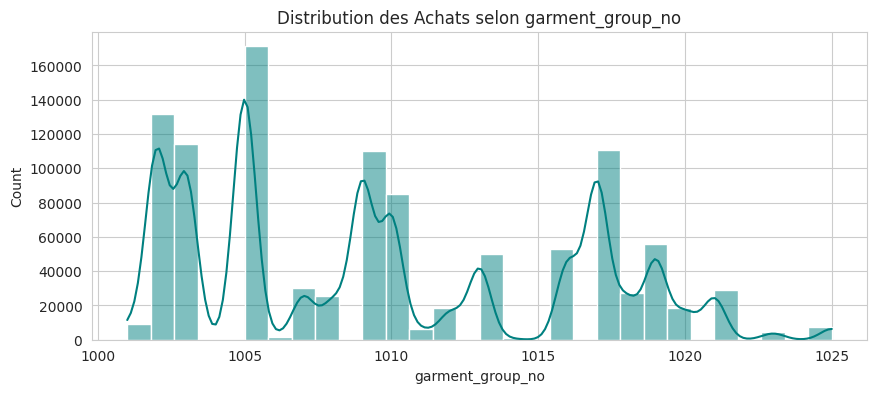

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : garment_group_name ---


/tmp/ipykernel_55/3762950128.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')


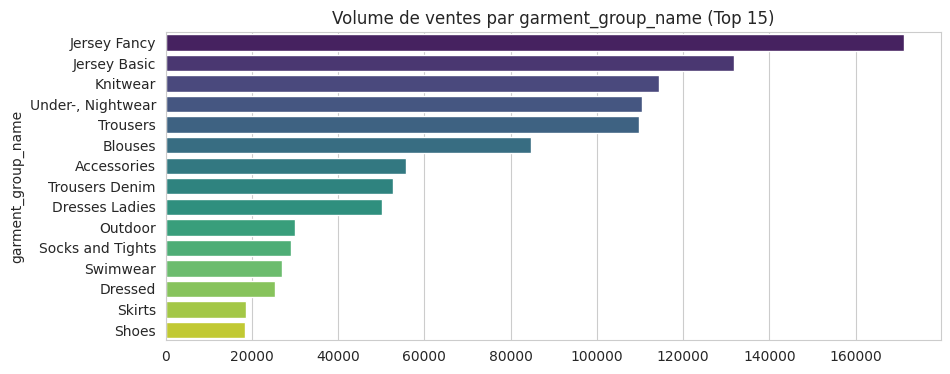

✅ SIGNAL : Regardez le graphique. S'il y a des pics, c'est une bonne feature.

--- ANALYSE DE : detail_desc ---
⚠️ BRUIT PROBABLE : 14249 valeurs uniques.
C'est trop précis pour généraliser (Risque d'Overfitting).


In [4]:
# --- DÉBUT DE L'ANALYSE DES FEATURES A GARDER ---

def analyzer_colonne(df, col_name):
    print(f"\n--- ANALYSE DE : {col_name} ---")
    
    # A. Est-ce un ID inutile ? (Trop de valeurs uniques)
    n_unique = df[col_name].nunique()
    ratio_unique = n_unique / len(df)
    
    if n_unique == 1:
        print(f"❌ REJETÉ : Valeur constante (inutile).")
        return "REJET"
    
    # Si c'est du texte avec trop de valeurs (ex: Code Postal, Description)
    if df[col_name].dtype == 'object' and n_unique > 1000:
        print(f"⚠️ BRUIT PROBABLE : {n_unique} valeurs uniques.")
        print("C'est trop précis pour généraliser (Risque d'Overfitting).")
        return "RISQUE"

    # B. Analyse Graphique
    plt.figure(figsize=(10, 4))
    
    # Si c'est un chiffre (Age, Prix) -> Histogramme
    if pd.api.types.is_numeric_dtype(df[col_name]):
        sns.histplot(df[col_name].dropna(), bins=30, kde=True, color='teal')
        plt.title(f"Distribution des Achats selon {col_name}")
        
    # Si c'est une catégorie (Couleur, Type) -> Barplot
    else:
        # On prend le Top 15 pour que ce soit lisible
        top_vals = df[col_name].value_counts().head(15)
        sns.barplot(x=top_vals.values, y=top_vals.index, palette='viridis')
        plt.title(f"Volume de ventes par {col_name} (Top 15)")
    
    plt.show()
    return "OK"

# 4. LANCEMENT DU SCAN SUR TOUTES LES COLONNES
# On exclut les IDs techniques et les dates
cols_to_ignore = ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']
cols_to_scan = [c for c in df_full.columns if c not in cols_to_ignore]

for col in cols_to_scan:
    analyzer_colonne(df_full, col)

# ***FEATURE ENGINEERING (Après l'EDA)***

In [44]:
#  CHARGEMENT SÉLECTIF (Basé sur l'analyse EDA)
# ------------------------------------------------------------------------------

df_trans = pd.read_csv('/kaggle/input/h-and-m-personalized-fashion-recommendations/transactions_train.csv')
df_trans['t_dat'] = pd.to_datetime(df_trans['t_dat'])


max_date = df_trans['t_dat'].max()
val_start_date = max_date - datetime.timedelta(weeks=2)
train_start_date = max_date - datetime.timedelta(weeks=16)
train_end_date = val_start_date
df = df_trans[df_trans['t_dat'] > val_start_date].copy()


val_start_date = max_date - datetime.timedelta(days=7)

train = df[df['t_dat'] <= val_start_date].copy()
val = df[df['t_dat'] > val_start_date].copy()




# FILTRAGE : Ne garder dans val que les users qui ont un historique
users_with_history = set(train['customer_id'].unique())
val_filtered = val[val['customer_id'].isin(users_with_history)].copy()

del df_trans
gc.collect()

# Clients : Age (signal fort), Status & Fréquence (activité)
CUST_COLS = ['customer_id', 'age', 'club_member_status', 'fashion_news_frequency']

# Articles : On a gardé l'apparence, la couleur, et le type (le reste était du bruit ou redondant)
ART_COLS = [
    'article_id', 
    'index_group_name',          # Homme/Femme/Enfant (Très discriminant)
    'product_type_name',         # Pantalon/Robe (Essentiel)
    'graphical_appearance_name', # Uni/Imprimé 
    'colour_group_name',         # Noir/Blanc...
    'perceived_colour_value_name', # Foncé/Clair
    'garment_group_name'         # Type de tissu/usage (Jersey/Knit...)
]

articles = pd.read_csv('/kaggle/input/h-and-m-personalized-fashion-recommendations/articles.csv', usecols=ART_COLS)
customers = pd.read_csv('/kaggle/input/h-and-m-personalized-fashion-recommendations/customers.csv', usecols=CUST_COLS)


In [31]:
#  FEATURE ENGINEERING (Nettoyage & Encodage)
# ------------------------------------------------------------------------------
print("Nettoyage et Encodage")

# Clients : On remplit les trous
customers['age'] = customers['age'].fillna(customers['age'].median())
customers['club_member_status'] = customers['club_member_status'].fillna('NOT_MEMBER')
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].replace(['None', 'NONE'], 'NONE').fillna('NONE')

# Encodage Clients (LabelEncoder)
for col in ['club_member_status', 'fashion_news_frequency']:
    customers[col] = LabelEncoder().fit_transform(customers[col])

# Encodage Articles (Tout le texte devient des chiffres pour XGBoost)
encode_cols = [c for c in ART_COLS if c != 'article_id']
for col in encode_cols:
    articles[col] = LabelEncoder().fit_transform(articles[col])

print("Données prêtes pour le modèle.")

# 1. Vérification de df_full (dataset complet)
print("\n📊 ANALYSE DE df_full :")
print(f"Shape: {df_full.shape}")
print("\nNombre de NaN par colonne :")
nan_counts = df_full.isnull().sum()
print(nan_counts[nan_counts > 0])  # Affiche seulement les colonnes avec NaN

if nan_counts.sum() == 0:
    print("✅ Aucun NaN dans df_full")
else:
    print(f"❌ Total de NaN: {nan_counts.sum()}")

Nettoyage et Encodage
Données prêtes pour le modèle.

📊 ANALYSE DE df_full :
Shape: (31548013, 14)

Nombre de NaN par colonne :
Series([], dtype: int64)
✅ Aucun NaN dans df_full


# MERGE OPTIMISE 
# ------------------------------------------------------------------------------
print("Merging...")
df_full = train.merge(customers, on='customer_id', how='left')
df_full = df_full.merge(articles, on='article_id', how='left')

print(f"Dataset final : {df_full.shape}")
print("Colonnes disponibles :", df_full.columns.tolist())

# ***SYSTEME HYBRIDE COMPLET (CLONE LIGHTFM)***

In [16]:

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

In [21]:
print("=== Démarrage du Système Hybride Complet ===\n")

# 1. PRÉPARATION DES DONNÉES

# A. Mapping IDs
print("Mapping des IDs...")
users = df_full['customer_id'].unique()
items = df_full['article_id'].unique()

user_to_idx = {v: k for k, v in enumerate(users)}
item_to_idx = {v: k for k, v in enumerate(items)}
idx_to_item = {k: v for v, k in item_to_idx.items()}

print(f"Users: {len(users)}, Items: {len(items)}")

# B. Matrice d'Interaction de base (Achats)
print("\nCréation de la matrice d'interactions...")
row = df_full['customer_id'].map(user_to_idx)
col = df_full['article_id'].map(item_to_idx)
data = np.ones(len(df_full))

interaction_matrix = sparse.coo_matrix(
    (data, (row, col)), 
    shape=(len(users), len(items))
).tocsr()

print(f"Matrice d'interactions: {interaction_matrix.shape}")

# 2. EXTRACTION DES FEATURES (DÉJÀ ENCODÉES)

print("\n=== Extraction des Features (pré-encodées) ===")

# Définition des colonnes de features
USER_FEATURES = ['age', 'club_member_status', 'fashion_news_frequency']
ITEM_FEATURES = ['product_type_name', 'graphical_appearance_name', 
                 'colour_group_name', 'perceived_colour_value_name', 
                 'index_group_name', 'garment_group_name']

# Extraction des entités UNIQUES
users_df = df_full[['customer_id'] + USER_FEATURES].drop_duplicates('customer_id')
items_df = df_full[['article_id'] + ITEM_FEATURES].drop_duplicates('article_id')

# Réindexer pour matcher l'ordre de nos mappings
users_df = users_df.set_index('customer_id').reindex(users).reset_index()
items_df = items_df.set_index('article_id').reindex(items).reset_index()

print(f"Users uniques: {len(users_df)}")
print(f"Items uniques: {len(items_df)}")

# 3. CRÉATION DES MATRICES DE FEATURES

print("\n=== Création des matrices de features ===")

# Comme tes features sont déjà encodées (entiers 0,1,2...),
# on les transforme en matrices One-Hot manuellement

def create_onehot_matrix(df, feature_cols):
    """Crée une matrice One-Hot à partir de features encodées"""
    matrices = []
    
    for col in feature_cols:
        # Conversion robuste en int
        col_values = df[col].astype(int)
        
        # Nombre de catégories uniques
        n_categories = int(col_values.max()) + 1
        n_samples = len(df)
        
        # Création de la matrice One-Hot sparse
        row_indices = np.arange(n_samples)
        col_indices = col_values.values
        data = np.ones(n_samples)
        
        onehot = sparse.coo_matrix(
            (data, (row_indices, col_indices)),
            shape=(n_samples, n_categories)
        ).tocsr()
        
        matrices.append(onehot)
    
    # Concaténation horizontale de toutes les features
    return sparse.hstack(matrices)

# USER FEATURES
user_features_matrix = create_onehot_matrix(users_df, USER_FEATURES)
print(f"User features matrix: {user_features_matrix.shape}")

# ITEM FEATURES
item_features_matrix = create_onehot_matrix(items_df, ITEM_FEATURES)
print(f"Item features matrix: {item_features_matrix.shape}")

# 4. RÉDUCTION DE DIMENSIONNALITÉ DES FEATURES

print("\n=== Réduction de dimensionnalité ===")

# On réduit les features à 20 dimensions pour les combiner avec SVD
user_svd_features = TruncatedSVD(n_components=30, random_state=42)
user_feat_reduced = user_svd_features.fit_transform(user_features_matrix)

item_svd_features = TruncatedSVD(n_components=30, random_state=42)
item_feat_reduced = item_svd_features.fit_transform(item_features_matrix)

print(f"User features réduites: {user_feat_reduced.shape}")
print(f"Item features réduites: {item_feat_reduced.shape}")



=== Démarrage du Système Hybride Complet ===

Mapping des IDs...
Users: 235277, Items: 29009

Création de la matrice d'interactions...
Matrice d'interactions: (235277, 29009)

=== Extraction des Features (pré-encodées) ===
Users uniques: 235277
Items uniques: 29009

=== Création des matrices de features ===
User features matrix: (235277, 107)
Item features matrix: (29009, 245)

=== Réduction de dimensionnalité ===
User features réduites: (235277, 20)
Item features réduites: (29009, 20)


In [41]:
# 5. SVD SUR LA MATRICE D'INTERACTIONS
# ==============================================================================

print("\n=== Entraînement SVD sur interactions ===")

svd_interactions = TruncatedSVD(n_components=100, random_state=42)
user_latent = svd_interactions.fit_transform(interaction_matrix)
item_latent = svd_interactions.components_.T

print(f"Facteurs latents Users: {user_latent.shape}")
print(f"Facteurs latents Items: {item_latent.shape}")

# ==============================================================================
# 6. HYBRIDATION : FUSION DES VECTEURS
# ==============================================================================

print("\n=== Hybridation : Fusion Latent + Features ===")

# On combine les vecteurs latents (SVD) avec les features réduites
# Pondération : 70% interactions, 30% features (ajustable)
WEIGHT_INTERACTIONS = 0.8
WEIGHT_FEATURES = 0.2

user_hybrid = np.hstack([
    user_latent * WEIGHT_INTERACTIONS, 
    user_feat_reduced * WEIGHT_FEATURES
])

item_hybrid = np.hstack([
    item_latent * WEIGHT_INTERACTIONS, 
    item_feat_reduced * WEIGHT_FEATURES
])

print(f"Vecteurs hybrides Users: {user_hybrid.shape}")
print(f"Vecteurs hybrides Items: {item_hybrid.shape}")

# Normalisation pour stabiliser les scores
user_hybrid = normalize(user_hybrid, axis=1)
item_hybrid = normalize(item_hybrid, axis=1)

print("Normalisation effectuée.")

# ==============================================================================
# 7. BASELINE GLOBALE

# Baseline globale (pour Cold Start)
print("\n=== Calcul baseline globale ===")
top_12_global = df_full['article_id'].value_counts().head(12).index.tolist()
print(f"Top 12 global: {top_12_global[:3]}...")


item_popularity = df_full['article_id'].value_counts().to_dict()
max_pop = max(item_popularity.values())

# 8. FONCTION DE PRÉDICTION HYBRIDE

# Pour les cold start users, utiliser les top items de leur profil démographique
# Par exemple, top items pour les users de même age/statut

def predict_hybrid(user_id, top_n=12, return_scores=False):
    """
    Version finale avec boost de popularité et fallback intelligent.
    
    Args:
        user_id: ID du client
        top_n: Nombre de recommandations à retourner (défaut: 12)
        return_scores: Si True, retourne aussi les scores (défaut: False)
    
    Returns:
        Liste des article_id recommandés (et optionnellement leurs scores)
    """
    
    if user_id in user_to_idx:
        # ====================================================================
        # CAS 1 : USER CONNU - Modèle Hybride avec boost de popularité
        # ====================================================================
        u_idx = user_to_idx[user_id]
        
        # Score collaboratif (similarité cosinus dans l'espace hybride)
        collab_scores = user_hybrid[u_idx] @ item_hybrid.T
        
        # Boost de popularité (normalisé entre 0 et 0.1)
        pop_boost = np.array([
            item_popularity.get(idx_to_item[i], 0) / max_pop * 0.1 
            for i in range(len(items))
        ])
        
        # Score final = 90% collaboratif + 10% popularité
        final_scores = collab_scores + pop_boost
        
        # Top N articles
        top_indices = np.argsort(final_scores)[-top_n:][::-1]
        top_items = [idx_to_item[i] for i in top_indices]
        
        if return_scores:
            top_scores = final_scores[top_indices]
            return top_items, top_scores
        
        return top_items
    
    else:
        # ====================================================================
        # CAS 2 : USER INCONNU (Cold Start) - Fallback démographique
        # ====================================================================
        demo_recs = get_demographic_recommendations(user_id, top_n)
        
        if return_scores:
            return demo_recs, []
        
        return demo_recs


def get_demographic_recommendations(user_id, top_n=12):
    """
    Recommandations basées sur le profil démographique du user.
    Utilisé pour le Cold Start (users jamais vus dans le train).
    
    Args:
        user_id: ID du client
        top_n: Nombre de recommandations
    
    Returns:
        Liste des article_id les plus populaires pour cette démographie
    """
    
    # Essayer de trouver le profil du user dans customers
    user_info = customers[customers['customer_id'] == user_id]
    
    if user_info.empty:
        # Pas d'info démographique → fallback sur le top global
        return top_12_global[:top_n]
    
    # Récupérer age et statut club
    age = user_info.iloc[0]['age']
    club = user_info.iloc[0]['club_member_status']
    
    # Trouver les users avec un profil similaire dans df_full
    # (même tranche d'âge ±5 ans, même statut club)
    similar_users = df_full[
        (df_full['age'] >= age - 5) & 
        (df_full['age'] <= age + 5) & 
        (df_full['club_member_status'] == club)
    ]
    
    if similar_users.empty:
        # Aucun user similaire → fallback sur le top global
        return top_12_global[:top_n]
    
    # Top items achetés par cette démographie
    demo_top_items = similar_users['article_id'].value_counts().head(top_n).index.tolist()
    
    # Compléter avec le top global si pas assez d'items
    if len(demo_top_items) < top_n:
        remaining = top_n - len(demo_top_items)
        demo_top_items.extend([x for x in top_12_global if x not in demo_top_items][:remaining])
    
    return demo_top_items[:top_n]


=== Entraînement SVD sur interactions ===
Facteurs latents Users: (235277, 100)
Facteurs latents Items: (29009, 100)

=== Hybridation : Fusion Latent + Features ===
Vecteurs hybrides Users: (235277, 120)
Vecteurs hybrides Items: (29009, 120)
Normalisation effectuée.

=== Calcul baseline globale ===
Top 12 global: [751471001, 909370001, 915526001]...


# ***TEST DU MODELE***

In [46]:
# 9. VALIDATION DU MODÈLE

import random
import time

print("\n=== VALIDATION DU MODÈLE SUR LE VAL SET ===")
# 1. Préparer le validation set
print("\nPréparation du validation set...")
val_full = val.merge(customers, on='customer_id', how='left')
val_full = val_full.merge(articles, on='article_id', how='left')
print(f"Validation set shape: {val_full.shape}")

# 2. Créer le ground truth (ce que chaque user a VRAIMENT acheté)
print("\nCréation du ground truth...")
val_ground_truth = val_full.groupby('customer_id')['article_id'].apply(list).to_dict()
all_users = list(val_ground_truth.keys())
print(f"Total Users disponibles: {len(all_users)}")

# --- OPTIMISATION ICI : ON PREND UN ÉCHANTILLON ---
SAMPLE_SIZE = 3000  # 3000 est suffisant pour une bonne estimation
random.seed(42)     # Pour que ce soit reproductible

# Si on a moins de 3000 users, on prend tout, sinon on échantillonne
if len(all_users) > SAMPLE_SIZE:
    sampled_users = random.sample(all_users, SAMPLE_SIZE)
    print(f"⚠️ Mode Rapide : Validation sur un échantillon de {SAMPLE_SIZE} utilisateurs.")
else:
    sampled_users = all_users
    print("Validation sur l'ensemble des utilisateurs.")

# Test (avec fallback intelligent)
print("\nTest Modèle en cours ...")
val_predictions = {}
start_time = time.time()

for i, user_id in enumerate(sampled_users):
    # On appelle ta fonction de prédiction
    val_predictions[user_id] = predict_hybrid(user_id) # ou predict_hybrid_top12 selon ton nom exact
    
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        print(f"  Progrès: {i + 1}/{len(sampled_users)} ({rate:.1f} users/sec)")

# . Calcul du score MAP@12 (Uniquement sur l'échantillon)
# On filtre le ground_truth pour ne garder que les gens qu'on a testés
sampled_ground_truth = {uid: val_ground_truth[uid] for uid in sampled_users}

print("\nCalcul du MAP@12...")

score = mapk(sampled_ground_truth, val_predictions, k=12)

# 3. Fonction de calcul MAP@12
def apk(actual, predicted, k=12):
    """Average Precision at K"""
    if len(predicted) > k:
        predicted = predicted[:k]
    
    score = 0.0
    num_hits = 0.0
    
    for i, p in enumerate(predicted):
        if p in actual:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    
    if not actual:
        return 0.0
    
    return score / min(len(actual), k)

def mapk(actual_dict, predicted_dict, k=12):
    """Mean Average Precision at K"""
    scores = []
    for user_id, actual in actual_dict.items():
        predicted = predicted_dict.get(user_id, [])
        scores.append(apk(actual, predicted, k))
    
    return np.mean(scores)


# 5. Calcul du score MAP@12
print("\nCalcul du MAP@12...")
score = mapk(val_ground_truth, val_predictions, k=12)

print(f"\n{'='*80}")
print(f"🎯 MAP@12 ESTIME (sur {len(sampled_users)} users): {score:.6f}")
print(f"{'='*80}")




=== VALIDATION DU MODÈLE SUR LES 7 DERNIERS JOURS ===

Préparation du validation set...
Validation set shape: (240311, 14)

Création du ground truth...
Total Users disponibles: 68984
⚠️ Mode Rapide : Validation sur un échantillon de 3000 utilisateurs.

Test Modèle en cours ...
  Progrès: 500/3000 (12.6 users/sec)
  Progrès: 1000/3000 (12.5 users/sec)
  Progrès: 1500/3000 (12.4 users/sec)
  Progrès: 2000/3000 (12.5 users/sec)
  Progrès: 2500/3000 (12.5 users/sec)
  Progrès: 3000/3000 (12.5 users/sec)

Calcul du MAP@12...

Calcul du MAP@12...

🎯 MAP@12 ESTIME (sur 3000 users): 0.000401
